# Classification Cat and Dog using CNN

Notebook ini membahas proses klasifikasi gambar kucing dan anjing menggunakan Convolutional Neural Network (CNN) dengan TensorFlow dan Keras. Setiap langkah akan dijelaskan secara detail agar mudah dipahami.

## Importing libraries

Pada bagian ini, kita akan mengimpor library yang diperlukan untuk membangun dan melatih model CNN, serta untuk memproses dataset gambar.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory

## Initialize Directory

Langkah ini bertujuan untuk menentukan direktori utama proyek dan dataset yang akan digunakan dalam pelatihan dan pengujian model.

In [2]:
dir = "D:\All Projects\CNN Basic" # Ganti dengan path ke direktori dataset Anda

## Importing Dataset

Bagian ini menjelaskan cara mengimpor dataset gambar kucing dan anjing, baik dari Kaggle maupun Google Drive, untuk digunakan dalam pelatihan model.

### Kaggle

Instruksi untuk mengunduh dataset dari Kaggle menggunakan kagglehub dan menampilkan path dataset yang telah diunduh.

**Penjelasan kode:**
- `import kagglehub`: Mengimpor library untuk mengakses dataset dari Kaggle.
- `path = kagglehub.dataset_download(...)`: Mengunduh dataset terbaru dari Kaggle dan menyimpan path hasil unduhan.
- `print(...)`: Menampilkan lokasi file dataset yang telah diunduh agar mudah ditemukan dan digunakan pada proses selanjutnya.

In [3]:
import kagglehub

path = kagglehub.dataset_download("sunilthite/cat-or-dog-image-classification")
print("Path to dataset files:", path)

c:\Users\fidhela\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\fidhela\.cache\kagglehub\datasets\sunilthite\cat-or-dog-image-classification\versions\1


### Pindahkan Dataset ke Folder Project

Langkah ini memindahkan dataset yang telah diunduh ke dalam folder proyek agar mudah diakses oleh script dan proses pelatihan.

In [4]:
import os
import shutil

src = path
dst = f"{dir}\\cat_dog_dataset"

if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print(f"Dataset berhasil disalin ke {dst}")
else:
    print(f"Folder tujuan {dst} sudah ada. Silakan hapus atau ganti nama folder tersebut sebelum menjalankan script ini.")

Folder tujuan D:\All Projects\CNN Basic\cat_dog_dataset sudah ada. Silakan hapus atau ganti nama folder tersebut sebelum menjalankan script ini.


### Google Drive

Alternatif lain untuk mengimpor dataset adalah dengan menggunakan Google Drive, terutama jika bekerja di Google Colab.

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

# !ls /content/drive/MyDrive/ComputerVision

In [6]:
# import zipfile
# import os

# # Membuat folder dataset jika belum ada
# if not os.path.exists('dataset'):
#     os.makedirs('dataset')

# # Menentukan path ke file zip
# zip_path = os.path.join('dataset', 'catcat.zip')
# extract_path = os.path.join('dataset', 'cat_dog_dataset')

# # Mengekstrak file zip
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

## Part 1: Pre-Processing

Bagian ini membahas tahapan pra-pemrosesan data, seperti augmentasi dan normalisasi gambar, sebelum digunakan untuk pelatihan model.

### Pre-Processing The Train Dataset

Penjelasan tentang bagaimana dataset pelatihan diproses, termasuk augmentasi data untuk meningkatkan variasi dan kualitas data pelatihan.

In [7]:
train_dataset = image_dataset_from_directory(
    dir + "/cat_dog_dataset/Train",
    image_size=(150, 150), # Ukuran gambar yang akan digunakan untuk pelatihan (150x150 piksel)
    batch_size=32, # Jumlah gambar yang akan diproses dalam satu batch selama pelatihan
    label_mode='binary' # 0 = kucing, 1 = anjing
)

# Menerapkan augmentasi data pada dataset pelatihan
train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'), # Membalik gambar secara horizontal secara acak
    tf.keras.layers.RandomRotation(0.1), # Rotasi acak hingga 10% dari sudut penuh (360 derajat)
    tf.keras.layers.RandomZoom(0.1), # Zoom acak hingga 10% dari ukuran asli
    tf.keras.layers.Rescaling(1./255) # Normalisasi piksel ke rentang [0, 1]
])

train_dataset = train_dataset.map(
    lambda x, y: (train_augmentation(x, training=True), y)
)

Found 23650 files belonging to 2 classes.


### Pre-Processing The Test Dataset

Penjelasan tentang pemrosesan dataset pengujian, termasuk normalisasi gambar agar sesuai dengan data pelatihan.

In [8]:
test_dataset = image_dataset_from_directory(
    dir + "/cat_dog_dataset/Test",
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary'
)

test_augmentation = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255)
])

test_dataset = test_dataset.map(
    lambda x, y: (test_augmentation(x, training=False), y)
)

Found 3863 files belonging to 2 classes.


## Part 2: Building the CNN

Bagian ini menjelaskan langkah-langkah membangun arsitektur Convolutional Neural Network (CNN) untuk klasifikasi gambar.

### Initializing the CNN

Langkah awal dalam membangun model CNN dengan menggunakan Sequential API dari Keras.

In [9]:
cnn = tf.keras.Sequential()

### Convolutional Layer 1

Penambahan layer konvolusi pertama untuk mengekstrak fitur dasar dari gambar input.

In [10]:
# Convolutional layer pertama untuk mengekstraksi fitur dasar
cnn.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=(150, 150, 3)
))

c:\Users\fidhela\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Pooling Layer

Menambahkan layer pooling untuk mengurangi dimensi fitur dan mencegah overfitting.

In [11]:
# Pooling layer kedua untuk mengurangi dimensi fitur setelah convolutional layer pertama

cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

### Adding Convolutional Layer 2

Menambahkan layer konvolusi kedua untuk mengekstrak fitur yang lebih kompleks dari gambar.

In [12]:
# Convolutional layer kedua untuk mengekstraksi fitur yang lebih kompleks
cnn.add(tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        # Tidak perlu mendefinisikan input_shape pada layer konvolusi kedua karena sudah otomatis terhubung dengan layer sebelumnya
))

# Pooling layer kedua untuk mengurangi dimensi fitur setelah convolutional layer kedua
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

### Flattening

Langkah ini meratakan hasil ekstraksi fitur dari layer konvolusi menjadi vektor satu dimensi sebelum masuk ke fully connected layer.

In [13]:
cnn.add(tf.keras.layers.Flatten())

### Fully Connected Layer

Menambahkan layer fully connected untuk menggabungkan fitur dan melakukan klasifikasi.

In [14]:
cnn.add(tf.keras.layers.Dense(256, activation='relu'))

# Menambahkan layer fully connected dengan 256 unit dan fungsi aktivasi ReLU
# 256 unit adalah jumlah neuron di layer fully connected, yang dapat disesuaikan berdasarkan kompleksitas dataset dan kebutuhan model.
# Fungsi aktivasi ReLU digunakan untuk menambahkan non-linearitas pada model, yang membantu model belajar pola yang

### Output

Layer output menghasilkan prediksi akhir berupa probabilitas kelas (kucing atau anjing) menggunakan fungsi aktivasi sigmoid.

In [15]:
cnn.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Menambahkan layer output dengan 1 unit dan fungsi aktivasi sigmoid untuk klasifikasi biner (kucing vs anjing)
# 1 unit digunakan untuk output karena ini adalah masalah klasifikasi biner (kucing vs anjing)
# Fungsi aktivasi sigmoid digunakan untuk menghasilkan output dalam rentang [0, 1], yang dapat diinterpretasikan sebagai probabilitas kelas positif (anjing)

### Compiling the CNN

Pada tahap ini, model CNN dikompilasi dengan optimizer, loss function, dan metrik evaluasi yang sesuai untuk klasifikasi biner.

In [16]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mengompilasi model CNN dengan optimizer Adam, fungsi loss binary crossentropy, dan metrik akurasi untuk evaluasi selama pelatihan

### Training and Evaluating the CNN

Model CNN dilatih menggunakan dataset pelatihan dan dievaluasi menggunakan dataset validasi untuk memantau performa.

In [17]:
cnn.fit(x=train_dataset, validation_data=test_dataset, epochs=25)

# Melatih model CNN menggunakan dataset pelatihan dan dataset pengujian untuk validasi selama 25 epoch

Epoch 1/25
740/740 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.6138 - loss: 0.6653 - val_accuracy: 0.6870 - val_loss: 0.5981
Epoch 2/25
740/740 ━━━━━━━━━━━━━━━━━━━━ 93s 126ms/step - accuracy: 0.6844 - loss: 0.5943 - val_accuracy: 0.6777 - val_loss: 0.6043
Epoch 3/25
740/740 ━━━━━━━━━━━━━━━━━━━━ 88s 119ms/step - accuracy: 0.7221 - loss: 0.5485 - val_accuracy: 0.7435 - val_loss: 0.5274
Epoch 4/25
740/740 ━━━━━━━━━━━━━━━━━━━━ 93s 126ms/step - accuracy: 0.7532 - loss: 0.5074 - val_accuracy: 0.7745 - val_loss: 0.4738
Epoch 5/25
740/740 ━━━━━━━━━━━━━━━━━━━━ 91s 123ms/step - accuracy: 0.7728 - loss: 0.4766 - val_accuracy: 0.7947 - val_loss: 0.4476
Epoch 6/25
740/740 ━━━━━━━━━━━━━━━━━━━━ 81s 110ms/step - accuracy: 0.7852 - loss: 0.4555 - val_accuracy: 0.8056 - val_loss: 0.4256
Epoch 7/25
740/740 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.7893 - loss: 0.4471 - val_accuracy: 0.8105 - val_loss: 0.4112
Epoch 8/25
740/740 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.7999 - loss: 0

### Saved Model

Bagian ini menjelaskan cara menyimpan dan memuat model CNN yang telah dilatih agar dapat digunakan kembali tanpa perlu melatih ulang.

In [22]:
import os

os.makedirs('saved_models', exist_ok=True)

cnn.save('saved_models/cat_dog_model.keras')
cnn.save('saved_models/cat_dog_model.h5') 
# Menyimpan model dalam format Keras (.keras) atau HDF5 (.h5)

loaded_model = tf.keras.models.load_model('saved_models/cat_dog_model.keras')

# Menyimpan model yang telah dilatih ke dalam folder 'saved_models' dengan nama 'cat_dog_model' dan kemudian memuat model tersebut untuk digunakan kembali di masa depan tanpa perlu melatih ulang.

### Making a single prediction

Langkah ini menunjukkan cara menggunakan model yang telah dilatih untuk memprediksi kelas dari satu gambar baru.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


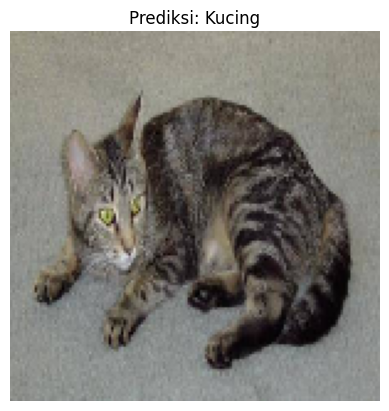

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

test_image_path = dir + r"\cat_dog_dataset\Test\Cat\cat.16.jpg"
test_image = image.load_img(test_image_path, target_size=(150, 150))
test_image_array = image.img_to_array(test_image) # Mengonversi gambar menjadi array NumPy untuk diproses oleh model CNN
test_image_array = np.expand_dims(test_image_array, axis=0) # Menambahkan dimensi batch pada array gambar sehingga bentuknya menjadi (1, 150, 150, 3) yang sesuai dengan input model CNN
test_image_array = test_image_array / 255.0 # Normalisasi piksel gambar ke rentang [0, 1] dengan membagi nilai piksel dengan 255.0

prediction = cnn.predict(test_image_array)
if prediction[0][0] != 1:
    predicted_class = 'Kucing'
else:
    predicted_class = 'Anjing'

plt.imshow(test_image)
plt.title(f"Prediksi: {predicted_class}")
plt.axis('off')
plt.show()

## Metrics Evaluation

Bagian ini membahas evaluasi performa model menggunakan metrik seperti classification report dan confusion matrix untuk mengukur akurasi dan kualitas prediksi.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━

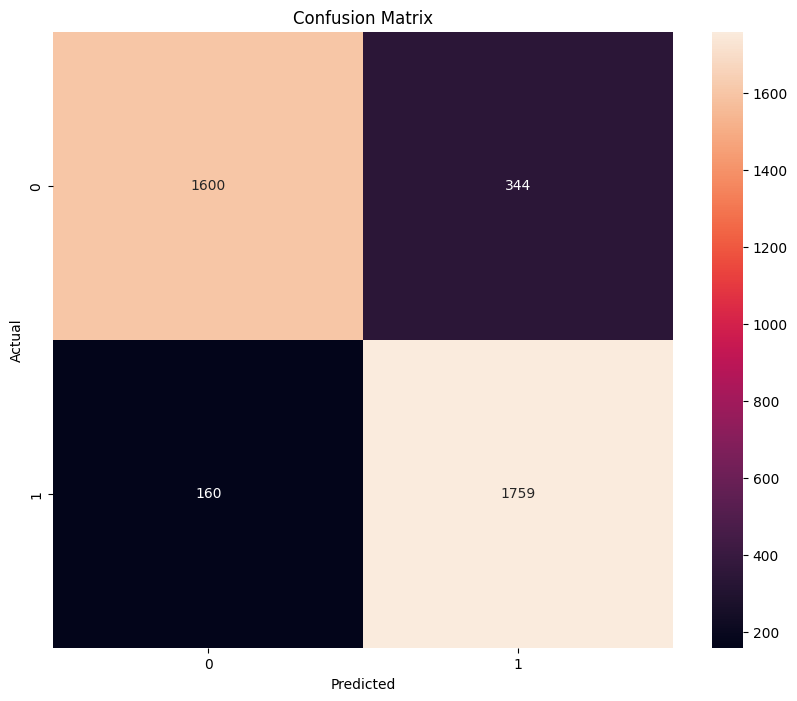

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = cnn.predict(images)
    predicted_labels = (predictions > 0.5).astype(int).flatten()
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Classification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

if not os.path.exists("images"):
    os.makedirs("images")
    plt.savefig("images/confusion_matrix.png")

plt.show()